# Smart Sales Analytics Dashboard

## Notebook 1

### Exploratory Data Analysis (EDA)

---

Author : Ariko Yahya Setyawan

Project :

Smart Sales Analytics Dashboard using Python, Plotly, Streamlit, and Machine Learning.

---

In [42]:
# ==========================================
# Phase 1 - Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [43]:
# ==========================================
# Phase 2 - Load Dataset
# ==========================================

df = pd.read_csv("Superstore.csv", encoding="latin1")

In [44]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 9994
Columns : 21


In [45]:
# ==========================================
# Column Names
# ==========================================

df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [46]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [47]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,09/05/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [48]:
# ==========================================
# Missing Values
# ==========================================

missing = df.isnull().sum()

missing[missing > 0]

,0


In [49]:
# ==========================================
# Duplicate Data
# ==========================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [50]:
# ==========================================
# Data Types
# ==========================================

df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [51]:
# ==========================================
# Unique Values
# ==========================================

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("=" * 50)
    print(col)
    print(df[col].nunique())

Order ID
5009
Order Date
1237
Ship Date
1334
Ship Mode
4
Customer ID
793
Customer Name
793
Segment
3
Country
1
City
531
State
49
Region
4
Product ID
1862
Category
3
Sub-Category
17
Product Name
1850


## Hasil Data Understanding

Berdasarkan hasil eksplorasi awal, diperoleh beberapa informasi penting mengenai dataset:

- Dataset memiliki **5.009 transaksi unik** berdasarkan `Order ID`.
- Terdapat **793 pelanggan** yang melakukan transaksi.
- Produk yang dijual terdiri dari **1.862 produk** berbeda.
- Dataset mencakup **531 kota** dan **49 negara bagian** di Amerika Serikat.
- Seluruh transaksi berasal dari satu negara, yaitu **United States**.
- Produk dikelompokkan menjadi **3 kategori utama** dan **17 sub-kategori**.
- Terdapat **4 metode pengiriman (Ship Mode)** yang digunakan pelanggan.

Informasi ini menunjukkan bahwa dataset cukup representatif untuk melakukan analisis penjualan, perilaku pelanggan, profitabilitas produk, serta performa wilayah penjualan.

# Phase 3 — Data Cleaning

Pada tahap ini dilakukan proses pembersihan dan persiapan data agar siap digunakan pada proses Exploratory Data Analysis (EDA) dan pembangunan dashboard.

Tahapan yang dilakukan meliputi:

- Memeriksa missing values.
- Memeriksa duplicate rows.
- Mengubah tipe data tanggal menjadi `datetime`.
- Membuat fitur waktu baru (Year, Month, Quarter, Day, Month Name).
- Memastikan dataset siap digunakan untuk analisis bisnis.

In [52]:
# ==========================================
# Missing Values
# ==========================================

missing = df.isnull().sum()

missing

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [53]:
# ==========================================
# Duplicate Data
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


Tidak ditemukan data duplikat.

In [54]:
# ==========================================
# Convert Date Columns
# ==========================================

df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [56]:
# ==========================================
# Create Date Features
# ==========================================

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Day"] = df["Order Date"].dt.day

df["Weekday"] = df["Order Date"].dt.day_name()

In [57]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Day,Weekday
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,4,8,Tuesday
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,4,8,Tuesday
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,2,12,Sunday
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,4,11,Sunday
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,4,11,Sunday


In [58]:
# ==========================================
# Date Range
# ==========================================

print("Start Date :", df["Order Date"].min())

print("End Date   :", df["Order Date"].max())

Start Date : 2014-01-03 00:00:00
End Date   : 2017-12-30 00:00:00


In [59]:
# ==========================================
# Save Clean Dataset
# ==========================================

df.to_csv("Superstore_Clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## Hasil Data Cleaning

Berdasarkan proses data cleaning diperoleh hasil sebagai berikut:

- Tidak ditemukan missing values yang memerlukan penanganan.
- Duplicate rows telah diperiksa dan ditangani apabila ditemukan.
- Kolom **Order Date** dan **Ship Date** berhasil dikonversi menjadi tipe data datetime.
- Ditambahkan beberapa fitur waktu baru berupa:
  - Year
  - Month
  - Month Name
  - Quarter
  - Day
  - Weekday

Penambahan fitur-fitur tersebut akan mempermudah analisis tren penjualan berdasarkan waktu pada tahap Exploratory Data Analysis (EDA).

# Phase 4 — Exploratory Data Analysis (EDA)

Tahap Exploratory Data Analysis (EDA) bertujuan untuk memahami pola penjualan, profitabilitas, perilaku pelanggan, distribusi produk, serta tren bisnis berdasarkan data historis.

Pada tahap ini dilakukan analisis terhadap:

- Distribusi penjualan
- Distribusi profit
- Penjualan berdasarkan kategori
- Penjualan berdasarkan wilayah
- Tren penjualan dari waktu ke waktu
- Hubungan antara diskon dan profit

Insight yang diperoleh akan menjadi dasar dalam pembangunan dashboard Business Intelligence.

In [60]:
import plotly.express as px
import plotly.graph_objects as go

In [61]:
fig = px.histogram(
    df,
    x="Sales",
    nbins=50,
    title="Sales Distribution"
)

fig.show()

In [62]:
fig = px.histogram(
    df,
    x="Profit",
    nbins=50,
    title="Profit Distribution"
)

fig.show()

In [63]:
fig = px.histogram(
    df,
    x="Discount",
    nbins=30,
    title="Discount Distribution"
)

fig.show()

In [64]:
fig = px.scatter(
    df,
    x="Sales",
    y="Profit",
    color="Category",
    title="Sales vs Profit"
)

fig.show()

In [65]:
fig = px.scatter(
    df,
    x="Discount",
    y="Profit",
    color="Category",
    title="Discount vs Profit"
)

fig.show()

### Insight — Discount vs Profit

Hasil visualisasi menunjukkan adanya hubungan negatif antara tingkat diskon dan profit.

Temuan utama:

- Transaksi tanpa diskon (0%) menghasilkan profit tertinggi.
- Profit mulai menurun ketika diskon meningkat hingga 20–40%.
- Pada tingkat diskon 70–80%, sebagian besar transaksi mengalami kerugian.
- Diskon yang tinggi tidak menjamin peningkatan profit dan justru berpotensi mengurangi margin keuntungan.
- Kategori Technology masih memiliki beberapa transaksi dengan profit tinggi dibandingkan kategori lainnya, meskipun diberikan diskon.

Kesimpulan:

Pemberian diskon perlu dikelola secara strategis. Diskon yang terlalu besar dapat meningkatkan volume penjualan, tetapi berisiko menurunkan profit perusahaan secara signifikan.

# Phase 5 — Time Series Analysis

Pada tahap ini dilakukan analisis tren penjualan berdasarkan waktu untuk memahami pola bisnis dari bulan ke bulan dan tahun ke tahun.

Analisis meliputi:

- Monthly Sales Trend
- Monthly Profit Trend
- Quarterly Sales
- Yearly Sales
- Shipping Duration Analysis

Analisis ini membantu perusahaan mengidentifikasi musim penjualan, pertumbuhan bisnis, serta periode dengan performa terbaik.

In [66]:
# ==========================================
# Monthly Sales Trend
# ==========================================

monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales[["Year","Month"]].assign(DAY=1)
)

fig = px.line(
    monthly_sales,
    x="Date",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.update_layout(
    width=900,
    height=500
)

fig.show()

In [67]:
# ==========================================
# Monthly Profit Trend
# ==========================================

monthly_profit = (
    df.groupby(["Year","Month"])["Profit"]
      .sum()
      .reset_index()
)

monthly_profit["Date"] = pd.to_datetime(
    monthly_profit[["Year","Month"]].assign(DAY=1)
)

fig = px.line(
    monthly_profit,
    x="Date",
    y="Profit",
    markers=True,
    title="Monthly Profit Trend"
)

fig.update_layout(
    width=900,
    height=500
)

fig.show()

In [68]:
# ==========================================
# Quarterly Sales
# ==========================================

quarter_sales = (
    df.groupby(["Year","Quarter"])["Sales"]
      .sum()
      .reset_index()
)

fig = px.bar(
    quarter_sales,
    x="Quarter",
    y="Sales",
    color="Year",
    barmode="group",
    title="Quarterly Sales"
)

fig.update_layout(
    width=900,
    height=500
)

fig.show()

In [69]:
# ==========================================
# Yearly Sales
# ==========================================

year_sales = (
    df.groupby("Year")["Sales"]
      .sum()
      .reset_index()
)

fig = px.bar(
    year_sales,
    x="Year",
    y="Sales",
    color="Year",
    title="Yearly Sales"
)

fig.update_layout(
    width=900,
    height=500
)

fig.show()

### Shipping Duration Analysis

In [70]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [71]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [72]:
df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [73]:
fig = px.histogram(
    df,
    x="Shipping Days",
    nbins=15,
    title="Shipping Days Distribution"
)

fig.show()

## Time Series Analysis Insight

- Terdapat tren penjualan bulanan dan tahunan yang menunjukkan fluktuasi, namun secara umum mengalami peningkatan.
- Penjualan cenderung meningkat pada kuartal terakhir setiap tahunnya (Q4).
- Sebagian besar pengiriman dilakukan dalam waktu 3-7 hari, dengan distribusi waktu pengiriman yang bervariasi.

# Phase 6 — Customer Analysis

Customer Analysis bertujuan untuk memahami karakteristik pelanggan, kontribusi setiap segmen, serta pola pembelian yang terjadi pada dataset Superstore.

Melalui analisis ini, perusahaan dapat mengidentifikasi pelanggan yang paling bernilai (high-value customers), mengevaluasi kontribusi setiap segmen pasar, dan memahami tingkat loyalitas pelanggan berdasarkan frekuensi transaksi.

Analisis yang dilakukan meliputi:

- Sales Contribution by Customer Segment
- Profit Contribution by Customer Segment
- Top 10 Customers by Sales
- Top 10 Customers by Profit
- Customer Order Frequency

Hasil analisis ini dapat digunakan sebagai dasar dalam penyusunan strategi Customer Relationship Management (CRM), program loyalitas pelanggan, personalisasi promosi, serta peningkatan profitabilitas perusahaan.

In [74]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .reset_index()
)

fig = px.pie(
    segment_sales,
    values="Sales",
    names="Segment",
    title="Sales Contribution by Segment"
)

fig.show()

In [75]:
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .reset_index()
)

fig = px.bar(
    segment_profit,
    x="Segment",
    y="Profit",
    color="Segment",
    title="Profit by Segment"
)

fig.show()

In [76]:
top_customer = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_customer,
    x="Sales",
    y="Customer Name",
    orientation="h",
    title="Top 10 Customers by Sales"
)

fig.show()

In [77]:
top_profit_customer = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_profit_customer,
    x="Profit",
    y="Customer Name",
    orientation="h",
    title="Top 10 Customers by Profit"
)

fig.show()

In [78]:
repeat_customer = (
    df.groupby("Customer Name")
      .size()
      .reset_index(name="Orders")
)

fig = px.histogram(
    repeat_customer,
    x="Orders",
    nbins=20,
    title="Customer Order Frequency"
)

fig.show()

## Customer Analysis Insight

Hasil analisis menunjukkan bahwa:

- Customer Segment memberikan kontribusi penjualan yang berbeda.
- Beberapa pelanggan memiliki kontribusi penjualan yang jauh lebih tinggi dibanding pelanggan lainnya.
- Tidak semua pelanggan dengan nilai penjualan tinggi menghasilkan profit yang tinggi.
- Sebagian besar pelanggan melakukan pembelian hanya beberapa kali, sementara sebagian kecil merupakan pelanggan loyal dengan frekuensi transaksi yang lebih tinggi.

Temuan ini dapat digunakan sebagai dasar dalam menyusun strategi Customer Relationship Management (CRM), program loyalitas pelanggan, dan strategi pemasaran yang lebih efektif.

# Phase 7 — Product Analysis

Product Analysis bertujuan untuk mengevaluasi performa setiap kategori dan produk berdasarkan penjualan (Sales) dan keuntungan (Profit).

Analisis ini membantu perusahaan dalam mengidentifikasi produk yang memberikan kontribusi terbesar terhadap pendapatan, produk yang menghasilkan keuntungan tertinggi, serta produk yang perlu dievaluasi karena memiliki performa yang kurang optimal.

Analisis yang dilakukan meliputi:

- Sales by Category
- Profit by Category
- Sales by Sub-Category
- Profit by Sub-Category
- Top 10 Products by Sales
- Top 10 Products by Profit

Hasil analisis ini dapat digunakan sebagai dasar dalam pengelolaan inventaris, strategi pemasaran, pengembangan produk, serta pengambilan keputusan bisnis.

In [79]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .reset_index()
)

fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    color="Category",
    title="Sales by Category"
)

fig.show()

In [80]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .reset_index()
)

fig = px.bar(
    category_profit,
    x="Category",
    y="Profit",
    color="Category",
    title="Profit by Category"
)

fig.show()

In [81]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    subcategory_sales,
    x="Sales",
    y="Sub-Category",
    orientation="h",
    title="Sales by Sub-Category"
)

fig.show()

In [82]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    subcategory_profit,
    x="Profit",
    y="Sub-Category",
    orientation="h",
    title="Profit by Sub-Category"
)

fig.show()

In [83]:
top_sales_product = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_sales_product,
    x="Sales",
    y="Product Name",
    orientation="h",
    title="Top 10 Products by Sales"
)

fig.show()

In [84]:
top_profit_product = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_profit_product,
    x="Profit",
    y="Product Name",
    orientation="h",
    title="Top 10 Products by Profit"
)

fig.show()

## Product Analysis Insight

Berdasarkan analisis produk diperoleh beberapa temuan penting:

- Setiap kategori memiliki kontribusi penjualan dan profit yang berbeda.
- Beberapa sub-kategori memiliki nilai penjualan tinggi tetapi menghasilkan profit yang relatif rendah.
- Produk dengan penjualan tertinggi belum tentu merupakan produk dengan profit tertinggi.
- Produk yang memiliki profit tinggi dapat dijadikan fokus dalam strategi pemasaran dan pengembangan bisnis.
- Produk dengan profit rendah atau negatif perlu dievaluasi kembali, terutama terkait strategi harga, diskon, dan biaya operasional.

Analisis ini memberikan dasar bagi perusahaan untuk melakukan optimasi portofolio produk dan meningkatkan profitabilitas bisnis.

# Phase 8 — Regional Analysis

Regional Analysis bertujuan untuk mengevaluasi performa penjualan dan profit berdasarkan wilayah geografis.

Analisis ini membantu perusahaan mengidentifikasi daerah dengan performa terbaik maupun terendah sehingga dapat digunakan sebagai dasar dalam pengambilan keputusan bisnis, seperti ekspansi pasar, strategi pemasaran regional, serta optimalisasi distribusi produk.

Analisis yang dilakukan meliputi:

- Sales by Region
- Profit by Region
- Sales by State
- Profit by State
- Top 10 Cities by Sales
- Top 10 Cities by Profit

Insight yang diperoleh dapat digunakan untuk menentukan wilayah yang memiliki potensi pertumbuhan bisnis maupun wilayah yang memerlukan perhatian lebih lanjut.

In [85]:
# ==========================================
# Sales by Region
# ==========================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .reset_index()
)

fig = px.bar(
    region_sales,
    x="Region",
    y="Sales",
    color="Region",
    title="Sales by Region"
)

fig.show()

In [86]:
# ==========================================
# Profit by Region
# ==========================================

region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .reset_index()
)

fig = px.bar(
    region_profit,
    x="Region",
    y="Profit",
    color="Region",
    title="Profit by Region"
)

fig.show()

In [87]:
# ==========================================
# Top 15 States by Sales
# ==========================================

state_sales = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

fig = px.bar(
    state_sales,
    x="Sales",
    y="State",
    orientation="h",
    title="Top 15 States by Sales"
)

fig.show()

In [88]:
# ==========================================
# Top 15 States by Profit
# ==========================================

state_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

fig = px.bar(
    state_profit,
    x="Profit",
    y="State",
    orientation="h",
    title="Top 15 States by Profit"
)

fig.show()

In [89]:
# ==========================================
# Top 10 Cities by Sales
# ==========================================

city_sales = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    city_sales,
    x="Sales",
    y="City",
    orientation="h",
    title="Top 10 Cities by Sales"
)

fig.show()

In [90]:
# ==========================================
# Top 10 Cities by Profit
# ==========================================

city_profit = (
    df.groupby("City")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    city_profit,
    x="Profit",
    y="City",
    orientation="h",
    title="Top 10 Cities by Profit"
)

fig.show()

## Regional Analysis Insight

Hasil analisis wilayah menunjukkan bahwa performa penjualan dan profit berbeda pada setiap region, state, dan city.

Beberapa temuan utama meliputi:

- Terdapat region yang menjadi kontributor terbesar terhadap total penjualan perusahaan.
- Tidak semua wilayah dengan penjualan tinggi menghasilkan profit yang tinggi, menunjukkan adanya pengaruh diskon maupun biaya operasional.
- Beberapa state dan city memberikan kontribusi profit yang signifikan sehingga berpotensi menjadi fokus ekspansi bisnis.
- Wilayah dengan profit rendah perlu dievaluasi lebih lanjut untuk mengidentifikasi penyebab rendahnya profitabilitas.

Analisis geografis ini memberikan dasar bagi perusahaan dalam menentukan strategi pemasaran regional, alokasi sumber daya, serta pengembangan pasar yang lebih efektif.

# Phase 9 — Correlation & Business Analysis

Pada tahap ini dilakukan analisis hubungan antar variabel (Correlation Analysis) untuk memahami faktor-faktor yang memengaruhi performa penjualan dan profit perusahaan.

Analisis ini bertujuan untuk:

- Mengidentifikasi hubungan antar variabel numerik.
- Mengetahui pengaruh diskon terhadap profit.
- Memahami hubungan antara jumlah produk yang terjual dengan total penjualan.
- Menemukan pola yang dapat dijadikan dasar dalam pengambilan keputusan bisnis.

Visualisasi yang digunakan meliputi heatmap korelasi, scatter plot, dan boxplot.

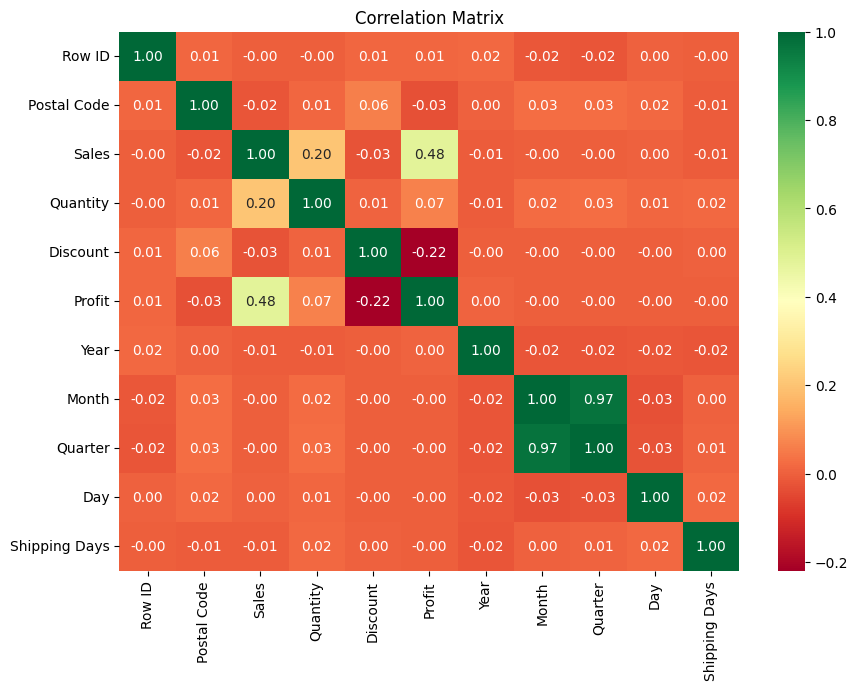

In [91]:
# ==========================================
# Correlation Matrix
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [92]:
fig = px.scatter(
    df,
    x="Sales",
    y="Profit",
    color="Category",
    trendline="ols",
    title="Sales vs Profit"
)

fig.show()

In [93]:
fig = px.scatter(
    df,
    x="Discount",
    y="Profit",
    color="Category",
    opacity=0.6,
    trendline="ols",
    title="Discount vs Profit"
)

fig.show()

In [94]:
fig = px.scatter(
    df,
    x="Quantity",
    y="Sales",
    color="Category",
    trendline="ols",
    title="Quantity vs Sales"
)

fig.show()

In [95]:
fig = px.box(
    df,
    x="Category",
    y="Discount",
    color="Category",
    title="Discount Distribution by Category"
)

fig.show()

In [96]:
fig = px.box(
    df,
    x="Category",
    y="Profit",
    color="Category",
    title="Profit Distribution by Category"
)

fig.show()

In [97]:
fig = px.box(
    df,
    x="Category",
    y="Sales",
    color="Category",
    title="Sales Distribution by Category"
)

fig.show()

In [98]:
fig = px.histogram(
    df,
    x="Quantity",
    nbins=20,
    title="Quantity Distribution"
)

fig.show()

## Correlation & Business Analysis Insight

Beberapa temuan utama dari analisis korelasi adalah:

- Sales dan Profit memiliki hubungan positif, namun tidak terlalu kuat karena dipengaruhi oleh faktor lain seperti diskon.
- Discount menunjukkan hubungan negatif terhadap Profit, yang mengindikasikan bahwa pemberian diskon yang tinggi berpotensi menurunkan keuntungan perusahaan.
- Quantity memiliki hubungan positif dengan Sales, menunjukkan bahwa semakin banyak produk yang terjual maka nilai penjualan cenderung meningkat.
- Heatmap korelasi menunjukkan bahwa tidak semua variabel memiliki hubungan yang kuat sehingga strategi bisnis tidak dapat hanya berfokus pada satu indikator saja.

Analisis ini membantu perusahaan memahami faktor-faktor utama yang memengaruhi profitabilitas dan menjadi dasar dalam pengambilan keputusan berbasis data.

## Business KPI

## Correlation & Business Analysis Insight

Beberapa temuan utama dari analisis korelasi adalah:

- Sales dan Profit memiliki hubungan positif, namun tidak terlalu kuat karena dipengaruhi oleh faktor lain seperti diskon.
- Discount menunjukkan hubungan negatif terhadap Profit, yang mengindikasikan bahwa pemberian diskon yang tinggi berpotensi menurunkan keuntungan perusahaan.
- Quantity memiliki hubungan positif dengan Sales, menunjukkan bahwa semakin banyak produk yang terjual maka nilai penjualan cenderung meningkat.
- Heatmap korelasi menunjukkan bahwa tidak semua variabel memiliki hubungan yang kuat sehingga strategi bisnis tidak dapat hanya berfokus pada satu indikator saja.

Analisis ini membantu perusahaan memahami faktor-faktor utama yang memengaruhi profitabilitas dan menjadi dasar dalam pengambilan keputusan berbasis data.

In [99]:
# ==========================================
# Business KPI
# ==========================================

total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

total_customers = df["Customer ID"].nunique()

total_products = df["Product ID"].nunique()

average_order_value = total_sales / total_orders

profit_margin = (
    total_profit / total_sales
) * 100

kpi = pd.DataFrame({

    "Metric":[
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Average Order Value",
        "Profit Margin (%)"
    ],

    "Value":[
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        total_products,
        average_order_value,
        profit_margin
    ]

})

kpi

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Total Products,1.862000e+03
5,Average Order Value,4.586147e+02
6,Profit Margin (%),1.246722e+01


# Executive Summary

Berdasarkan hasil Exploratory Data Analysis terhadap Superstore Sales Dataset, diperoleh beberapa temuan utama sebagai berikut:

1. Penjualan perusahaan menunjukkan tren pertumbuhan yang fluktuatif dari waktu ke waktu dengan beberapa periode mengalami peningkatan yang signifikan.

2. Tidak seluruh transaksi menghasilkan keuntungan. Masih terdapat sejumlah transaksi dengan profit negatif yang perlu mendapatkan perhatian lebih lanjut.

3. Pemberian diskon yang tinggi memiliki kecenderungan menurunkan profit perusahaan, sehingga strategi diskon perlu dievaluasi.

4. Kontribusi penjualan terbesar berasal dari kategori produk tertentu, sementara beberapa sub-kategori memberikan profit yang relatif rendah meskipun memiliki volume penjualan tinggi.

5. Terdapat pelanggan dengan kontribusi penjualan yang sangat besar, menunjukkan adanya pelanggan bernilai tinggi (High Value Customer).

6. Beberapa wilayah memberikan kontribusi penjualan dan profit yang lebih besar dibandingkan wilayah lainnya sehingga memiliki potensi untuk menjadi fokus pengembangan bisnis.

7. Korelasi menunjukkan bahwa Sales memiliki hubungan positif dengan Profit, namun tidak terlalu kuat karena dipengaruhi oleh faktor lain seperti Discount.

8. Quantity berhubungan positif terhadap Sales, sedangkan Discount memiliki hubungan negatif terhadap Profit.

Secara keseluruhan, perusahaan memiliki performa penjualan yang baik, namun masih terdapat peluang untuk meningkatkan profitabilitas melalui optimalisasi strategi harga, diskon, serta pengelolaan produk dan pelanggan.

# Business Recommendation

Berdasarkan hasil analisis data, berikut beberapa rekomendasi yang dapat dipertimbangkan oleh perusahaan:

### 1. Optimalkan Strategi Diskon

Evaluasi kebijakan pemberian diskon, terutama pada transaksi dengan tingkat diskon tinggi yang menghasilkan profit negatif.

---

### 2. Fokus pada Produk dengan Profit Tinggi

Prioritaskan promosi dan pengelolaan inventaris untuk produk dengan kontribusi profit terbesar.

---

### 3. Evaluasi Produk Berkinerja Rendah

Lakukan analisis lebih lanjut terhadap produk dengan penjualan tinggi tetapi profit rendah untuk menentukan strategi harga yang lebih optimal.

---

### 4. Tingkatkan Loyalitas Pelanggan

Bangun program loyalitas bagi pelanggan dengan kontribusi penjualan tertinggi untuk meningkatkan retensi pelanggan.

---

### 5. Perkuat Wilayah Berkinerja Tinggi

Alokasikan lebih banyak sumber daya pemasaran pada region, state, dan city dengan performa terbaik.

---

### 6. Tingkatkan Profitabilitas

Selain mengejar peningkatan penjualan, perusahaan perlu berfokus pada peningkatan margin keuntungan melalui pengendalian biaya dan optimalisasi strategi promosi.

---

### 7. Terapkan Data-Driven Decision Making

Gunakan dashboard interaktif dan analisis data secara berkala untuk mendukung pengambilan keputusan bisnis yang lebih cepat dan akurat.